In [2]:

import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display_latex

In [3]:
#-----------------------------------------Initial conditions for Figure 8------------------------------------------
M = np.array([1, 1, 1])
N = np.size(M)
# Time
dt = 0.01
timesteps = 100000
time = np.linspace(0, dt*timesteps+1, timesteps)

x0 = np.array([[-0.97000436,  0.24308753, 0], 
               [0.97000436, -0.24308753, 0],
               [ 0.0, 0.0, 0]])

v0 = np.array([[0.4662036850, 0.4323657300, 0], 
               [0.4662036850, 0.4323657300, 0],
               [-2*0.4662036850, -2*0.4323657300, 0]])


In [41]:
#-----------------------------------------Initial Conditions for Two Body Problem----------------------------------
M = np.array([1, 1])
N = np.size(M)
G = 1

# Time
dt = 0.005
timesteps = 10000
time = np.linspace(0, dt*timesteps+1, timesteps)

#Initial conditions for Figure 8 
x0 = np.array([[ 1, 0, 0],
               [-1, 0, 0]])


R = np.linalg.norm(x0[1]-x0[0])
totalM = M[0] + M[1]
v_esc = np.sqrt(2 * G * totalM / R) / N #Escape Velocity
v_rel = np.sqrt(G * totalM / R)

v0= np.array([[0, M[1]/totalM * v_rel, 0],
            [0, -M[0]/totalM * v_rel, 0]])



In [4]:
def acceleration(x, M, G):
    N = np.shape(x)[0]
    a = np.zeros((N, 3))
    U = 0
    for i in range(N):
        for j in range(i+1, N):
            x_i, x_j = x[i, :], x[j, :]
            r_ij = x_j - x_i
            r_ij_norm = np.linalg.norm(x_j - x_i)
            
            #Calculate force exerted on i by each j
            a_ij = (G*M[i]*M[j]/(r_ij_norm**3+1e-7)) * (r_ij)
            a[i, :] += a_ij/M[i]
            a[j, :] -= a_ij/M[j]
            
            #Calculating potentials
            U_ij = -G*M[i]*M[j]/(r_ij_norm)
            U += U_ij 
    return a, U

In [ ]:
def nBodyLeapfrog(M, x0, v0, time):
    
    #Constants
    G = 1
    N = np.size(M)
    colors = plt.cm.viridis(np.linspace(0, 1, N))
    timesteps = np.shape(time)[0]
    dt = time[1] - time[0]

    #Centre of Mass
    CoM0 = np.zeros(3)
    v_CoM0 = np.zeros(3)
    total_mass = np.sum(M, axis= 0)
    
    for i in range(N):
        CoM0 += M[i] * x0[i, :]/total_mass
        v_CoM0 += M[i] * v0[i, :]/total_mass

    #Position/Velocity Vectors
    x = np.zeros((N, 3, timesteps))
    v = np.zeros((N, 3, timesteps))
    v_plushalf = np.zeros((N, 3, timesteps))
    
    x[:, :, 0] = x0-CoM0
    v[:, :, 0] = v0-v_CoM0

    _, U0 = acceleration(x[:, :, 0], M, G)

    #Conserved Quantities
    T = np.zeros(timesteps) # KE
    U = np.zeros(timesteps) # PE
    P = np.zeros((3, timesteps)) # Momentum
    L = np.zeros((3, timesteps)) # Ang. Momentum

    T[0] = np.sum(0.5*M*np.linalg.norm(v[:, :, 0], axis = 1)**2)
    U[0] = U0 
    
    for i in range(N):
        x_i = x[i, :, 0]
        u_i = v[i, :, 0]
        P_i = M[i] * u_i
        L_i = np.cross(x_i, P_i)
        
        P[:, 0] += P_i
        L[:, 0] += L_i 
        
    for k in range(timesteps-1):
        a_k, U_k = acceleration(x[:, :, k], M, G)
        v_plushalf[:, :, k] = v[:, :, k] + 0.5*a_k*dt

        x[:, :, k+1] = x[:, :, k] + v_plushalf[:, :, k]*dt
        
        a_kp1, U_kp1 = acceleration(x[:, :, k+1], M, G)
        v[:, :, k+1] = v_plushalf[:, :, k] + 0.5*a_kp1*dt  

        T[k+1] = np.sum(0.5*M@np.linalg.norm(v[:, :, k+1], axis = 1)**2)
        U[k+1] = U_kp1

        for i in range(N):
            x_i = x[i, :, k+1]
            v_i = v[i, :, k+1]
            P_i = M[i] * v_i
            L_i = np.cross(x_i, P_i)
            
            P[:, k+1] += P_i
            L[:, k+1] += L_i 
    #Conserved Quantities Errors
    E = T + U
    P0, P_error_denominator = P[:, 0], P[:, 0]
    L0, L_error_denominator = L[:, 0], L[:, 0]
    E_error = np.abs((E-E[0])/E[0])
    
    if np.linalg.norm(P[:, 0]) == 0:
        print("Triggered")
        for i in range(N):
            v0_i = v0[i, :]
            if np.linalg.norm(v0_i) != 0:
                P_error_denominator = M[i]*v0_i
                break
    
    if np.linalg.norm(L[:, 0]) == 0:
        for i in range(N):
            x0_i = x0[i, :]
            v0_i = v0[i, :]
            P0_i = M[i]*v0_i
            L0_i = np.cross(x0_i, P0_i)
            if np.linalg.norm(L0_i) != 0:
                L_error_denominator = L0_i
                break
    
    P_error = np.linalg.norm((P-P0[:, None]), axis = 0)/np.linalg.norm(P_error_denominator)
    L_error = np.linalg.norm((L-L0[:, None]), axis = 0)/np.linalg.norm(L_error_denominator)
    
    # Plotting the orbits
    fig1, axa = plt.subplots()
    #axa.scatter(CoM0[0], CoM0[1], color = 'black', label = "Centre of Mass")
    for i in range(N):
        axa.plot(x[i, 0, :], x[i, 1, :], linestyle = 'None', color = colors[i], label = f"Body {i}", marker = 'o', markersize = 1)
        axa.scatter(x[i, 0, 0], x[i, 1, 0], color = colors[i], label = f"Mass {i} Start ")
        axa.scatter(x[i, 0, -1], x[i, 1, -1], facecolor = 'None', edgecolor = colors[i], label = f"Mass {i} End ")
        plt.gca().set_aspect('equal', adjustable='box')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

    fig2, axb = plt.subplots(3, 1, figsize = (10, 15))
    axb[0].plot(time, E_error)
    axb[0].set_title("Energy Error")
    axb[1].plot(time, P_error)
    axb[1].set_title("Momentum Error")
    axb[2].plot(time, L_error)
    axb[2].set_title("Ang. Momentum Error")
    plt.tight_layout()
    return x, v

Triggered


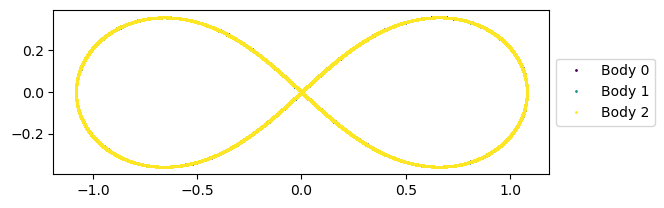

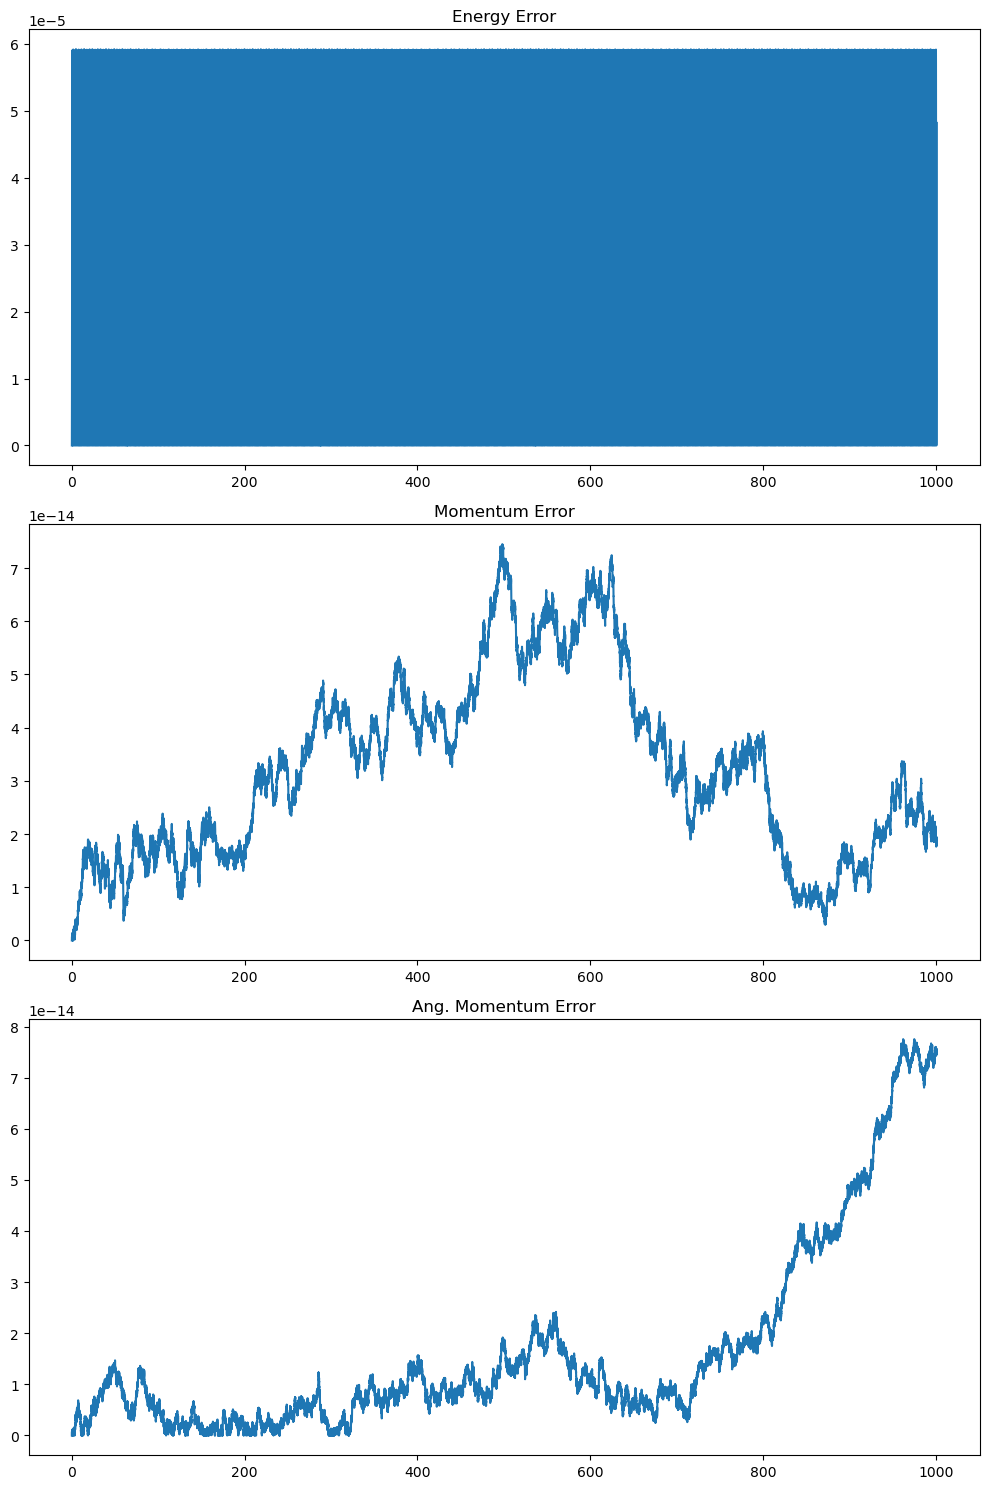

In [12]:
x_Lf, v_Lf = nBodyLeapfrog(M, x0, v0, time)

In [52]:
def timestep(x, v, eta, N):
    dt = np.inf
    for i in range(N):
        for j in range(i+1, N):
            x_i, x_j = x[i, :], x[j, :]
            r_ij = x_j - x_i
            v_i, v_j = v[i, :], v[j, :]
            v_ij = v_j - v_i
            dt_ij = np.linalg.norm(r_ij)/(np.linalg.norm(v_ij)+1e-10)
            dt = np.minimum(dt, dt_ij)
    return eta*dt


Triggered
Triggered
Triggered
Triggered
Triggered
Triggered
Triggered
Triggered
Triggered
Triggered


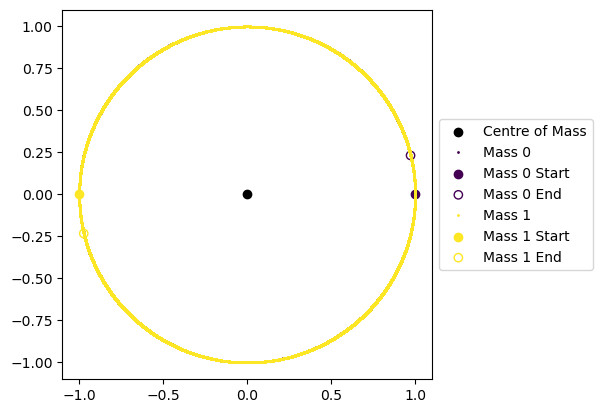

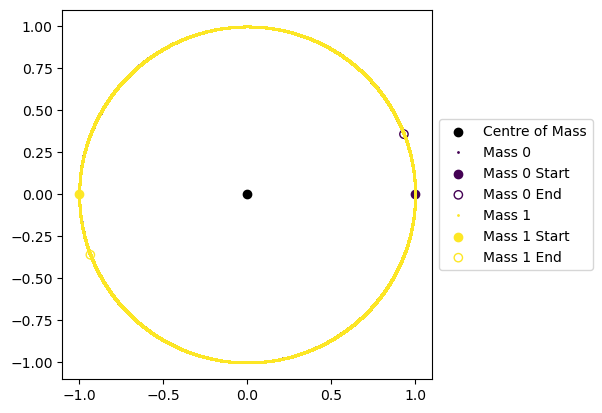

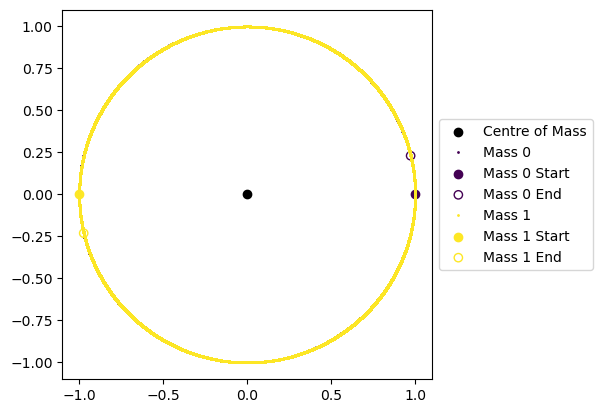

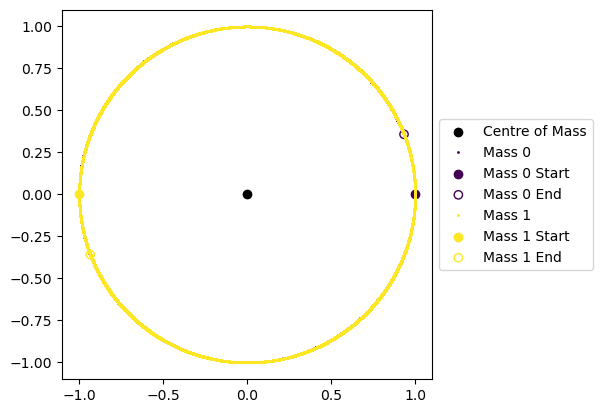

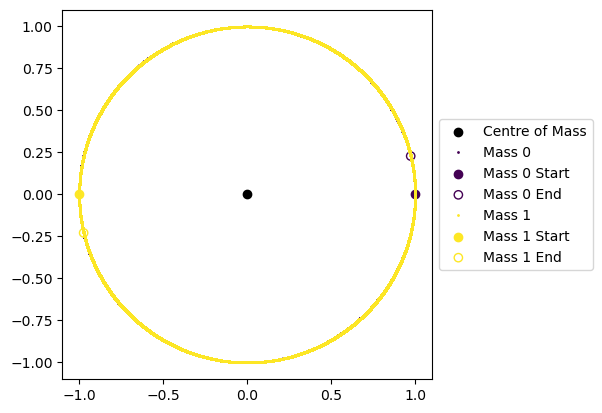

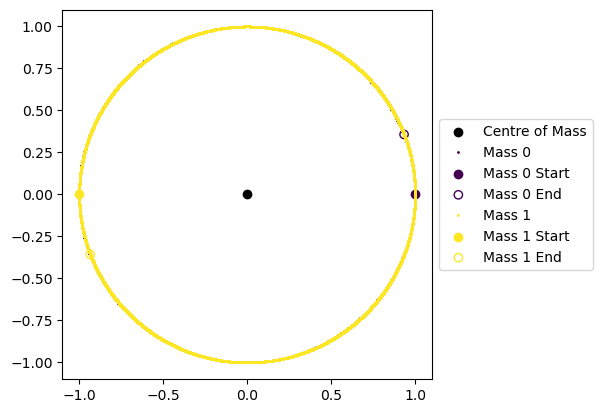

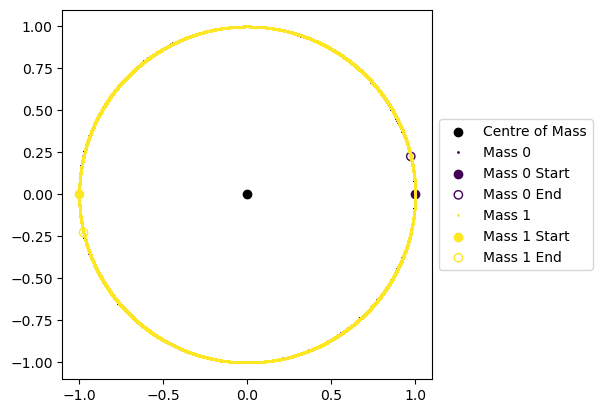

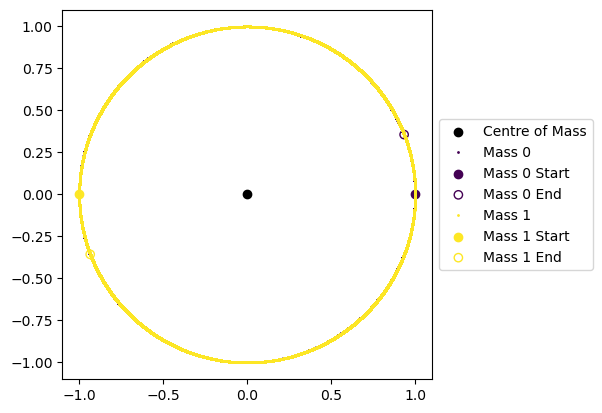

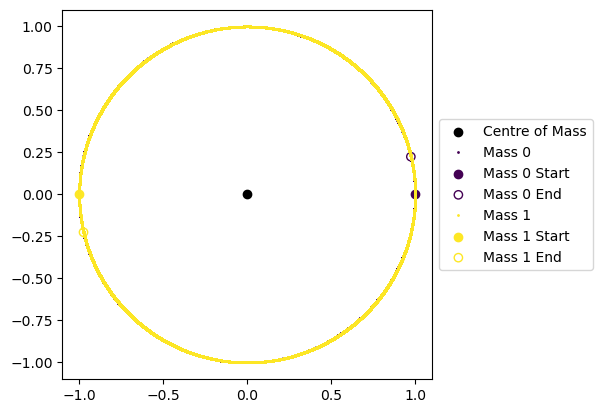

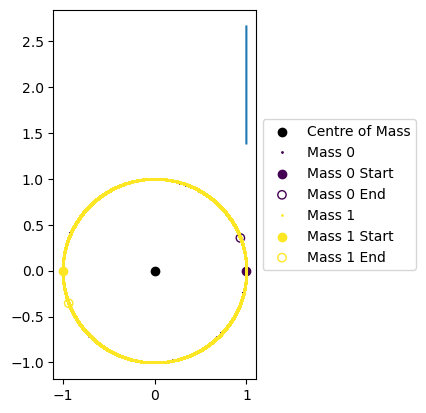

In [53]:
k = np.linspace(1, 1.00005,5)
s = np.zeros(5)

for i in range(5):
    v0= np.array([[0, k[i]*M[1]/totalM * v_rel, 0],
            [0, -k[i]*M[0]/totalM * v_rel, 0]])
    dt = 0.001
    timesteps = 100000
    time = np.linspace(0, dt*timesteps+1, timesteps)
    E_1 = max(nBodyLeapfrog(M, x0, v0, time))
    
    dt = 0.0005
    timesteps = 100000
    time = np.linspace(0, dt*timesteps+1, timesteps)
    E_2 = max(nBodyLeapfrog(M, x0, v0, time))
    s[i] = E_1/E_2

plt.plot(k, s)

In [70]:
def nBodyLeapfrog_Variabledt(M, x0, v0, time):
    
    #Constants
    G = 1
    N = np.size(M)
    colors = plt.cm.viridis(np.linspace(0, 1, N))
    timesteps = np.shape(time)[0]

    #Centre of Mass
    CoM0 = np.zeros(3)
    v_CoM0 = np.zeros(3)
    total_mass = np.sum(M, axis= 0)
    
    for i in range(N):
        CoM0 += M[i] * x0[i, :]/total_mass
        v_CoM0 += M[i] * v0[i, :]/total_mass

    a0, U0 = acceleration(x0, M, G)

    #Position/Velocity Vectors
    x = np.zeros((N, 3, timesteps))
    v = np.zeros((N, 3, timesteps))
    v_plushalf = np.zeros((N, 3, timesteps))
    
    x[:, :, 0] = x0-CoM0
    v[:, :, 0] = v0-v_CoM0

    #Conserved Quantities
    T = np.zeros(timesteps) # KE
    U = np.zeros(timesteps) # PE
    P = np.zeros((3, timesteps)) # Momentum
    L = np.zeros((3, timesteps)) # Ang. Momentum

    T[0] = np.sum(0.5*M*np.linalg.norm(v[:, :, 0], axis = 1)**2)
    U[0] = U0 
    
    for i in range(N):
        x_i = x[i, :, 0]
        u_i = v[i, :, 0]
        P_i = M[i] * u_i
        L_i = np.cross(x_i, P_i)
        
        P[:, 0] += P_i
        L[:, 0] += L_i 
        
    for k in range(timesteps-1):
        dt_k = timestep(x[:, :, k], v[:, :, k], 0.1, N)
        a_k, U_k = acceleration(x[:, :, k], M, G)
        v_plushalf[:, :, k] = v[:, :, k] + 0.5*a_k*dt_k

        x[:, :, k+1] = x[:, :, k] + v_plushalf[:, :, k]*dt_k
        
        a_kp1, U_kp1 = acceleration(x[:, :, k+1], M, G)
        v[:, :, k+1] = v_plushalf[:, :, k] + 0.5*a_kp1*dt_k 

        T[k+1] = np.sum(0.5*M@np.linalg.norm(v[:, :, k], axis = 1)**2)
        U[k+1] = U_kp1

        for i in range(N):
            x_i = x[i, :, k+1]
            v_i = v[i, :, k+1]
            P_i = M[i] * v_i
            L_i = np.cross(x_i, P_i)
            
            P[:, k+1] += P_i
            L[:, k+1] += L_i 
    #Conserved Quantities Errors
    E = T + U
    P0, P_error_denominator = P[:, 0], P[:, 0]
    L0, L_error_denominator = L[:, 0], L[:, 0]
    E_error = np.abs((E-E[0])/E[0])
    
    if np.linalg.norm(P[:, 0]) == 0:
        for i in range(N):
            v0_i = v0[i, :]
            if np.linalg.norm(v0_i) != 0:
                P_error_denominator = M[i]*v0_i
                break
    
    if np.linalg.norm(L[:, 0]) == 0:
        for i in range(N):
            x0_i = x0[i, :]
            v0_i = v0[i, :]
            P0_i = M[i]*v0_i
            L0_i = np.cross(x0_i, P0_i)
            if np.linalg.norm(L0_i) != 0:
                L_error_denominator = L0_i
                break
    
    P_error = np.linalg.norm((P-P0[:, None]), axis = 0)/np.linalg.norm(P_error_denominator)
    L_error = np.linalg.norm((L-L0[:, None]), axis = 0)/np.linalg.norm(L_error_denominator)
    
    # Plotting the orbits
    fig1, axa = plt.subplots()
    axa.scatter(0, 0, color = 'black', label = "Centre of Mass")
    for i in range(N):
        axa.plot(x[i, 0, :], x[i, 1, :], color = colors[i], label = f"Mass {i}")
        axa.scatter(x0[i, 0], x0[i, 1], color = colors[i], label = f"Mass {i} Start ")
        axa.scatter(x[i, 0, -1], x[i, 1, -1], facecolor = 'None', edgecolor = colors[i], label = f"Mass {i} End ")
        #plt.xlim(-2, 2)
        #plt.ylim(-2, 2)
        plt.gca().set_aspect('equal', adjustable='box')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

    fig2, axb = plt.subplots(1, 3)
    axb[0].plot(time, E_error)
    axb[0].set_title("Energy Error")
    axb[1].plot(time, P_error)
    axb[1].set_title("Momentum Error")
    axb[2].plot(time, L_error)
    axb[2].set_title("Ang. Momentum Error")
    plt.tight_layout()
    return x, v

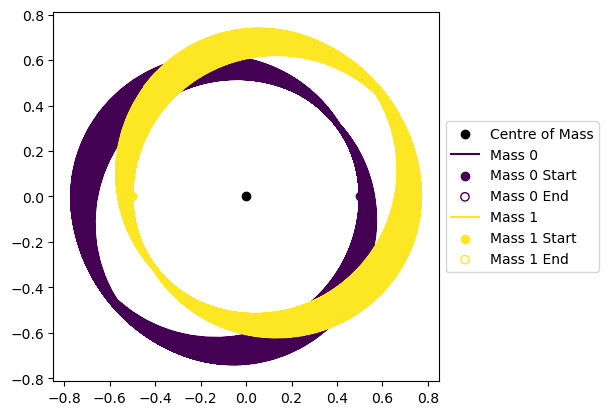

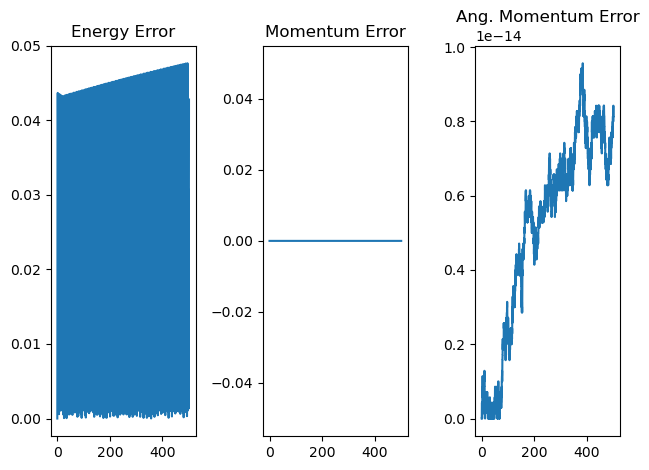

In [71]:
x, v = nBodyLeapfrog_Variabledt(M, x0, v0, time)